# Scikit-learn Workflow
* Getting the data ready
* Picking a model to suit your problem
* Fitting the model to the data and making a prediction
* Evaluating the model
* Improving through experimentation
* Save and reload your trained model

# Standard libraries to be imported
* Numpy
* Pandas
* Matplotlib
  

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Quick overview of the workflow


### 1. Getting the data ready

In [2]:
heart_diseases = pd.read_csv(r"C:\Users\Fagbohunka Vincent\Documents\Programming\Data Analytics Docs\Jupyter\Matplotlib\heart-disease.csv")
heart_diseases

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
# Create X (feature mtarix)
x = heart_diseases.drop("target", axis = 1)

# Create y (labels)
y = heart_diseases["target"]

### 2. Choose the right model

In [4]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

# We'll keep the defaul hyperparameter
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

### 3. Fit the model to the training data

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [6]:
clf.fit(x_train, y_train);

In [7]:
y_pred = clf.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0], dtype=int64)

In [8]:
y_test

80     1
136    1
148    1
26     1
127    1
      ..
9      1
202    0
182    0
280    0
86     1
Name: target, Length: 61, dtype: int64

### 4. Evaluating the model

In [9]:
# Evaluating the model on the training data and test data 
clf.score(x_train, y_train)

1.0

In [10]:
clf.score(x_test, y_test)

0.819672131147541

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.80      0.78        25
           1       0.86      0.83      0.85        36

    accuracy                           0.82        61
   macro avg       0.81      0.82      0.81        61
weighted avg       0.82      0.82      0.82        61



In [12]:
confusion_matrix(y_test, y_pred)

array([[20,  5],
       [ 6, 30]], dtype=int64)

In [13]:
accuracy_score(y_test, y_pred)

0.819672131147541

### 5. Improving the model

In [14]:
# Try different amount of n_estimators
np.random.seed(42)
for i in range(10, 100, 10):
    print(f"Trying model with {i} our estimator...")
    clf = RandomForestClassifier(n_estimators=i).fit(x_train, y_train)
    print(f"Total accuracy on test set: {clf.score(x_test, y_test) * 100:.2f}%")
    print(" ")

Trying model with 10 our estimator...
Total accuracy on test set: 77.05%
 
Trying model with 20 our estimator...
Total accuracy on test set: 78.69%
 
Trying model with 30 our estimator...
Total accuracy on test set: 75.41%
 
Trying model with 40 our estimator...
Total accuracy on test set: 81.97%
 
Trying model with 50 our estimator...
Total accuracy on test set: 80.33%
 
Trying model with 60 our estimator...
Total accuracy on test set: 80.33%
 
Trying model with 70 our estimator...
Total accuracy on test set: 80.33%
 
Trying model with 80 our estimator...
Total accuracy on test set: 81.97%
 
Trying model with 90 our estimator...
Total accuracy on test set: 78.69%
 


### 6. Saving the model

In [15]:
import pickle

pickle.dump(clf, open("random_forest_ model_1.pkl", "wb"))

In [16]:
# loading the model
loaded_model = pickle.load(open("random_forest_ model_1.pkl", "rb"))
loaded_model.score(x_test, y_test)

0.7868852459016393

## A. Getting the data ready


#### 1.1 Make sure it's all numerical

In [17]:
car_sales = pd.read_csv("car-sales-extended.csv")
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [18]:
len(car_sales)

1000

In [19]:
car_sales.dtypes

Make             object
Colour           object
Odometer (KM)     int64
Doors             int64
Price             int64
dtype: object

In [20]:
# Split the data into x/y
x = car_sales.drop("Price", axis=1)
y = car_sales["Price"]


In [21]:
# Build machine learning model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

In [22]:
# Turning categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features =["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot, categorical_features)], remainder="passthrough")

transformed_x = transformer.fit_transform(x)
transformed_x 

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]])

In [23]:
pd.DataFrame(transformed_x)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [24]:
x_train, x_test, y_train, y_test = train_test_split(transformed_x, y, test_size=0.2)
model.fit(x_train, y_train)
model.score(x_test, y_test)


0.259996418764183

# What if there were missing values?
* Filll them with some values(also known as imputation).
* Remove the samples with missing data altogether.

In [25]:
# import car sales missing data
car_sales_missing = pd.read_csv("car-sales-extended-missing-data.csv")
car_sales_missing

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [26]:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

### Option 1: Filling the missing data with pandas

In [27]:
# Fill the "Make" column
car_sales_missing["Make"] = car_sales_missing["Make"].fillna("missing")

#Fill the "Colour" column
car_sales_missing["Colour"] = car_sales_missing["Colour"].fillna("missing")

#Fill the "Odometer (KM)" column
car_sales_missing["Odometer (KM)"] = car_sales_missing["Odometer (KM)"].fillna(car_sales_missing["Odometer (KM)"].mean())

#Fill the "Doors" column
car_sales_missing["Doors"] = car_sales_missing["Doors"].fillna(4)

In [28]:
car_sales_missing.isna().sum()

Make              0
Colour            0
Odometer (KM)     0
Doors             0
Price            50
dtype: int64

In [29]:
# REmove rows with missing price values
car_sales_missing.dropna(inplace=True)
car_sales_missing.isna().sum()

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [30]:
len(car_sales_missing)

950

In [31]:
X = car_sales_missing.drop("Price", axis=1)
Y = car_sales_missing["Price"]

cat = ["Make", "Colour", "Doors"]
ohe = OneHotEncoder()
tfm = ColumnTransformer([("one_hot", ohe, cat)], remainder="passthrough")

tfm_x = tfm.fit_transform(X)
tfm_x

<950x15 sparse matrix of type '<class 'numpy.float64'>'
	with 3800 stored elements in Compressed Sparse Row format>

In [32]:
# np.random.seed(42)
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import train_test_split
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
# model.fit(X_train, Y_train)
# model.score(X_test, Y_test)

### Option 2: Filling missing values with Sklearn

In [33]:
car_missing = pd.read_csv("car-sales-extended-missing-data.csv")
car_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [34]:
car_missing.dropna(subset=["Price"], inplace=True)
car_missing.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [35]:
# Split into X & Y
X = car_missing.drop("Price", axis=1)
Y = car_missing["Price"]

In [36]:
# Fill missing values with Sklearn
from sklearn.impute import SimpleImputer

#Fill categorical values with "missing" & numerical values with mean
cat_imputer = SimpleImputer(strategy="constant", fill_value="missing")
door_imputer = SimpleImputer(strategy="constant", fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

# Define the columns
cat_feature = ["Make", "Colour"]
door_feature = ["Doors"]
num_feature = ["Odometer (KM)"]

# Create an imputer(something that fills missing data)
imputer = ColumnTransformer([
    ("cat_imputer", cat_imputer, cat_feature),
    ("door_imputer", door_imputer, door_feature),
    ("num_imputer", num_imputer, num_feature)
])

# Transform the data
filled_X = imputer.fit_transform(X)
filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], dtype=object)

In [37]:
car_sales_filled = pd.DataFrame(filled_X, columns=["Make", "Colour", "Doors", "Odometer (KM)"])
car_sales_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [38]:
# Turning categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features =["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot, categorical_features)], remainder="passthrough")

transformed_x = transformer.fit_transform(car_sales_filled)
transformed_x 

<950x15 sparse matrix of type '<class 'numpy.float64'>'
	with 3800 stored elements in Compressed Sparse Row format>

In [39]:
# fitting  a model

np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(transformed_x, Y, test_size=0.2)
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, Y_train)
model.score(X_test, Y_test)

0.21990196728583944

In [40]:
len(car_sales), len(car_sales_filled)

(1000, 950)

## B. Choosing the right etsimator/algorithm for our problem

Scikit-learn uses estimator as another term for machine learning model or algorithm.

1. Unstructured data: Deep learning or Transfer Learning
2. Structured data: Ensemble method(RandomForest)
    * Clasiffication - predicting whether a sample is one thing or another
    * Regression - Predicting a number


## C. Fit the model on the data
This is carried out by passing the x(train) and y(train) variables as arguments in the `.fit()` method of the model.
* `x` = features, feature variables, data
* `y` = labels, targets, target variables

## D. Make predictions using a machine learning model
There are two ways:
* `.predict()` function
* .`predict_proba()`.

##### 1. Using prediction function

In [41]:
# Create X (feature mtarix)
x = heart_diseases.drop("target", axis = 1)

# Create y (labels)
y = heart_diseases["target"]

from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

# We'll keep the default hyperparameter
clf.get_params()

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

clf.fit(x_train, y_train);

y_pred = clf.predict(x_test)
y_pred

array([0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1], dtype=int64)

In [42]:
np.array(y_test)

array([1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0], dtype=int64)

In [43]:
# Compare predictions to truth labels to evaluate the model

y_pred = clf.predict(x_test)
np.mean(y_pred==y_test)

0.8524590163934426

In [44]:
clf.score(x_test, y_test)

0.8524590163934426

In [45]:
#without using classification model

from sklearn.metrics import accuracy_score
accuracy_score(y_pred, y_test)

0.8524590163934426

##### 2. Using `.predict_proba()` function

In [46]:
# predict_proba returns probability pf classification model

clf.predict_proba(x_test[:5])

array([[0.69, 0.31],
       [0.59, 0.41],
       [0.03, 0.97],
       [0.8 , 0.2 ],
       [0.93, 0.07]])

In [47]:
# let's predict on the same data

clf.predict(x_test[:5])

array([0, 0, 1, 0, 0], dtype=int64)

###### From the `predict_proba()`, it indicates the probabilities of all the target categories for each row or data

### `.predict()` can also be used for regression model

The prredictions must be compared to the truth using:
from `sklearn.metrics` import `mean_absolute_error`

## E. Evaluation of a model
Three way to evaluate:
* Estimator `.score()` method(this has been observed initially)
* The `scoring` parameter
* Prolem-specific metric functions.

#### Evaluating a model using the `scoring` parameter
This method cross validates the model based on the number of times stated for cross validation(e.g. model of test size of 20% will be cross validated(cv) 5 times ). In other words, a model can trained on 5 different versions of trainig datasets, and evaluated on 5 different versions of the test datasets if the`cv` is set to 5.

In [48]:
# Create x (feature mtarix)
x = heart_diseases.drop("target", axis = 1)

# Create y (labels)
y = heart_diseases["target"]

from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

# We'll keep the default hyperparameter
clf.get_params()

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

clf.fit(x_train, y_train);

In [49]:
clf.score(x_test, y_test)

0.8360655737704918

In [50]:
from sklearn.model_selection import cross_val_score

cross_val_score(clf, x, y, cv=5)

array([0.81967213, 0.90163934, 0.7704918 , 0.78333333, 0.76666667])

In [51]:
np.random.seed(42)
# Single training and test split score
clf_single_score = clf.score(x_test, y_test)

# Take the mean of 5-fold cross validatiion score
clf_cross_val_score = np.mean(cross_val_score(clf, x, y, cv=5))

# compare the two
clf_single_score, clf_cross_val_score

(0.8360655737704918, 0.8248087431693989)

In [52]:
# Default scoring parameter of classifier = mean accuracy i.e. clf.score

In [53]:
# Scoring parameter set none by default
cross_val_score(clf, x, y,cv=5, scoring=None)

array([0.78688525, 0.86885246, 0.80327869, 0.78333333, 0.76666667])

##### Classification model evaluation metrics

1. Accuracy
2. Area under ROC curve
3. Confusion matrix
4. Classification report


**Accuracy**


In [54]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

x = heart_diseases.drop("target", axis=1)
y= heart_diseases["target"]

clf = RandomForestClassifier(n_estimators=100)
cross_val_score = cross_val_score(clf, x, y, cv= 5)
cross_val_score

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [55]:
np.mean(cross_val_score)

0.8248087431693989

In [56]:
print(f'Heart Disease Classifier cross-Validated Accuracy: {np.mean(cross_val_score) * 100:.2f}%.')

Heart Disease Classifier cross-Validated Accuracy: 82.48%.


#### Area under the Receiver Operating Characteristic curve(AUC/ROC)
* Area under curve(AUC)
* ROC

ROC curves are a comparision of a model's true positive rate (tpr) versus a model's false positive rate(fpr).

1. FPR : It answer the question "out of all the negative samples, how many did the model wrongly classify as positive?"
   
                                FPR:FP/(FP+TN)

   
3. TPR : It answer the question "out of all the positive samples, how many did the model correctly classify as positive?"
   
                                TPR = TP/(TP+FN)

3. Threshold: This sets the standards of the model to classify the samples to different targets. E.g. if 0.7 is the threshold, then probabilities >= 0.7 would be positive.


* True positive = model predicts true when it's actually true
* False Positive = model predicts true when it's actually false
* True negative = model predicts false when it's acually false
* False negative = model predicts negative when it's actually true
  

In [57]:
# Create x_test....e.t.c

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [58]:
from sklearn.metrics import  roc_curve
# Fit the classifier
clf.fit(x_train, y_train)

# Make predictions with probabilities
y_probs = clf.predict_proba(x_test)
 
y_probs[:10], len(y_probs)

(array([[0.51, 0.49],
        [0.17, 0.83],
        [0.51, 0.49],
        [0.72, 0.28],
        [0.43, 0.57],
        [0.12, 0.88],
        [0.3 , 0.7 ],
        [0.97, 0.03],
        [0.15, 0.85],
        [0.4 , 0.6 ]]),
 61)

In [59]:
y_probs_positive = y_probs[:,1]
y_probs_positive[:10]

array([0.49, 0.83, 0.49, 0.28, 0.57, 0.88, 0.7 , 0.03, 0.85, 0.6 ])

In [60]:
# calculate fpr, tpr and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

# Check fpr
fpr, thresholds

(array([0.        , 0.03448276, 0.03448276, 0.03448276, 0.03448276,
        0.03448276, 0.03448276, 0.06896552, 0.06896552, 0.06896552,
        0.10344828, 0.10344828, 0.13793103, 0.13793103, 0.13793103,
        0.20689655, 0.20689655, 0.20689655, 0.27586207, 0.37931034,
        0.37931034, 0.48275862, 0.48275862, 0.55172414, 0.55172414,
        1.        ]),
 array([ inf, 1.  , 0.98, 0.95, 0.92, 0.88, 0.87, 0.86, 0.85, 0.83, 0.81,
        0.8 , 0.77, 0.76, 0.71, 0.66, 0.6 , 0.57, 0.49, 0.4 , 0.38, 0.31,
        0.28, 0.23, 0.2 , 0.  ]))

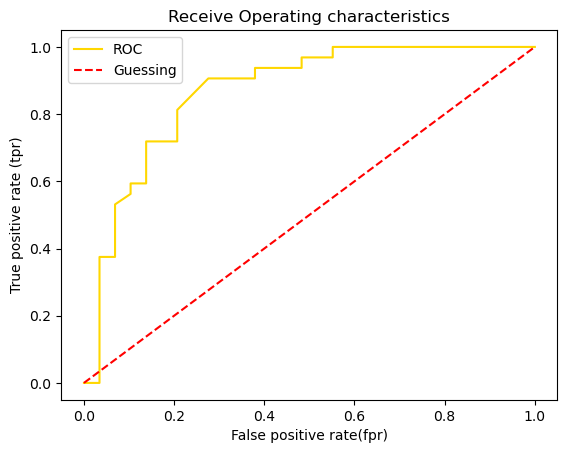

In [61]:
# Create a function for plotting ROC curves
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    """"
    Plots a ROC curve given the false positive rate(fpr)
    and true positive rate(tpr) of a model.
    """
    # Plot roc curve
    plt.plot(fpr, tpr, color="gold", label="ROC")
    #Plot line with no predictive power(baseline)
    plt.plot([0,1], [0,1], color="red", linestyle="--", label="Guessing")

    #Customize the plot
    plt.xlabel("False positive rate(fpr)")
    plt.ylabel("True positive rate (tpr)")
    plt.title("Receive Operating characteristics")
    plt.legend()
    plt.show()


plot_roc_curve(fpr, tpr)

In [62]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_probs_positive)

0.8669181034482759

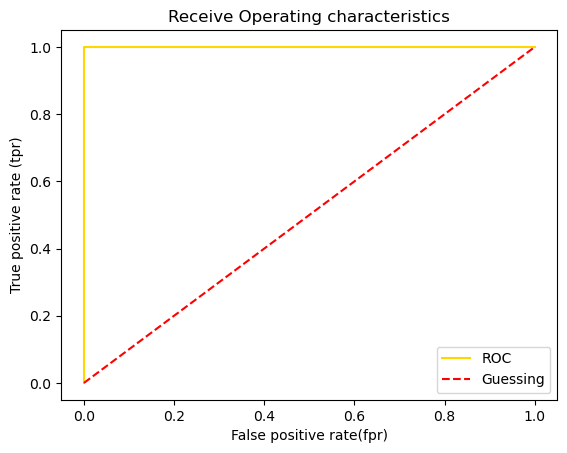

In [63]:
# Plot perfect ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_test)
plot_roc_curve(fpr, tpr)

In [64]:
# Perfect AUC score
roc_auc_score(y_test, y_test)

1.0

**Confusion Matrix**

A Confusion Matrix is a quick way to compare the labels a model predicts and the actual labels it was supposed to predict.In essence, it gives an idea of confusion.

The diagonal values are the True Positive and True negative.




In [65]:
y_preds = clf.predict(x_test)

confusion_matrix(y_test, y_preds)

array([[23,  6],
       [ 6, 26]], dtype=int64)

In [66]:
# Visualization using pd crosstabs
pd.crosstab(y_test, y_preds, rownames=["Actual_y"], colnames=["Predicted_y"])
# From the output, the lower triangular matrix - diagonal = The False Negative
# From the output, the upper triangular matrix - diagonal = The False positive

Predicted_y,0,1
Actual_y,,
0,23,6
1,6,26


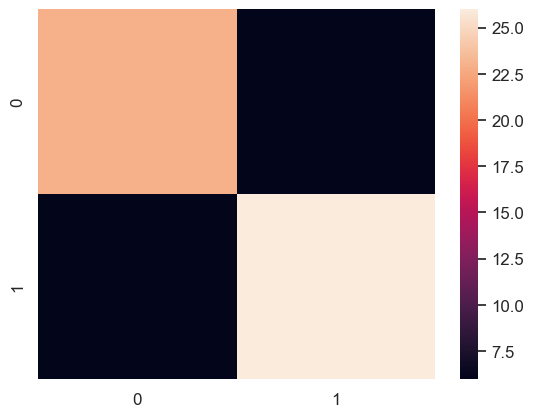

In [70]:
# Make Confusion Matrix more visual with Seaborn.heatmap()
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Set the font scale
sns.set(font_scale=1.1)

# Create a Confusion Matrix
conf_matx = confusion_matrix(y_test, y_preds)

#plot using sns
sns.heatmap(conf_matx)
plt.show()

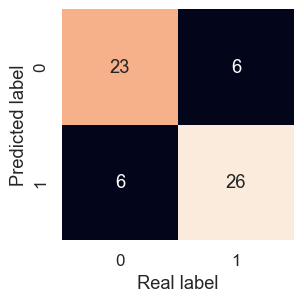

In [68]:
def plot_conf_matx(conf_matx):
    """
    Plots a confusion matrix using Seaborn's heatmap
    """
    fig, ax = plt.subplots(figsize=(3,3))
    ax = sns.heatmap(conf_matx,
                    annot=True, # Annotates the boxes with conf_matx info
                    cbar=False)
    plt.xlabel("Real label")
    plt.ylabel("Predicted label")
    plt.show();

plot_conf_matx(conf_matx)

**Classification Report**

* Precision - "Out of all the samples the model predicted as a member of a target, how many were actually a member?"
* Recall - "Out of all the actual members of a target, how many did the model find?"
* F1-score - It is the harmonic mean of precision and recall.

  `F1 =  2[(Precision * recall) / (Precision * Recall)]`
    
* Support - The number of actual samples belonging to each target.
* Acurracy - The percentage of correctness of the predictions

  `(TP+TN)/Total Samples`
  
* Macro Average - This treats every target equally, regardless of how many samples each class has.

  `(Metric[1] + Metric[1] + ... + Metric[n])/n`
  
* Weighted Average - This considers the number of samples in each target
  `Summation(Support[i] * metric[i])/summation(Support[i])`        

In [71]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        29
           1       0.81      0.81      0.81        32

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [72]:
pd.DataFrame((classification_report(y_test, y_preds, output_dict=True)))

,0,1,accuracy,macro avg,weighted avg
precision,0.793103,0.8125,0.803279,0.802802,0.803279
recall,0.793103,0.8125,0.803279,0.802802,0.803279
f1-score,0.793103,0.8125,0.803279,0.802802,0.803279
support,29.000000,32.0000,0.803279,61.000000,61.000000


###### Regression model evaluation metrics

1. R^2(R-Squared) or Coefficient of determination: This is the output of `.score()` of the model. It compares model predictions to the mean of the target. It ranges from negative infinity(very poor) to 1. If it predicts the mean of the target, it is 1, and if is range of numbers , it is 0
2. Mean Absolute Error
3. Mean Squared Error